In [1]:
import sys, os
import glob
import json
import random
from typing import List, Dict
from dataclasses import dataclass, field

import torch
torch.set_default_dtype(torch.float64)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openmm.app as app

sys.path.insert(0, '..')
from cmm.forcefield import CMMForceField
from cmm.units import HARTREE2KCAL, BOHR2ANG, BOHR2NM
#from cmm.develop.data import EdaData, EspData, DipoleData, PolarizabilityData
from cmm.develop.optimize import Trainer2, Optimizer
from cmm.develop.metrics import plot_correlation, plot_eda_scan
from cmm.develop.extract_params import extract_bond_angle_eq, extract_multipoles

from cmm.misc_utils import *

/home/heindelj/OneDrive/Documents/Coding_Projects/python_development/pyCMM/notebooks/../cmm/develop/optimize.py:352: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if key is not 'int':


In [2]:
na_water_pdb = "/home/heindelj/research/Teresa/reactive_force_fields/reference_data/CMM_Data/ion_water/train_test_splits/na_water_wb97xv_qzvppd_train.pdb"
na_water_csv = "/home/heindelj/research/Teresa/reactive_force_fields/reference_data/CMM_Data/ion_water/train_test_splits/na_water_wb97xv_qzvppd_train.csv"

In [3]:
def report_eda_cluster(trainer, data, **kwargs):
    with torch.no_grad():
        res, ref = trainer.evaluate(data)
    
    keys = ['total', 'perm_elec', 'pol', 'ct', 'pauli', 'disp']
    fig, axes = plt.subplots(2, 3, figsize=(9, 6), constrained_layout=True)
    axes = axes.flatten()
    for i in range(len(keys)):
        ax = axes[i]
        key = keys[i]
        if key == 'total':
            plot_correlation(ref['int'], res[key], xlabel='QM (kcal/mol)', ylabel='CMM (kcal/mol)', ax=ax)
        else:
            plot_correlation(ref[key], res[key], xlabel='QM (kcal/mol)', ylabel='CMM (kcal/mol)', ax=ax)
        ax.set_title(key.upper())

In [4]:
@dataclass
class EdaData:
    topologies: List[app.Topology]
    coords: List[torch.Tensor]
    energies: Dict[str, torch.Tensor]
    eda_df: pd.DataFrame = None
    num: int = field(init=False)

    def __post_init__(self):
        self.num = int(len(self.coords))

    @classmethod
    def from_csv_file(cls, pdb_file, csv_file):
        topologies, coords = cls.get_openmm_topologies_and_coordinates(pdb_file)
        coords = [torch.from_numpy(xyz) for xyz in coords]

        eda_df = pd.read_csv(csv_file)
        enes_ref = {
            'perm_elec': eda_df['cls_elec'].values / 4.184,
            'pauli': eda_df['mod_pauli'].values / 4.184,
            'ct': eda_df['ct'].values / 4.184,
            'pol': eda_df['pol'].values / 4.184,
            'disp': eda_df['disp'].values / 4.184,
            'int': eda_df['int'].values / 4.184
        }
        enes_ref = {key: torch.tensor(enes_ref[key]) for key in enes_ref}

        data = cls(topologies, coords, enes_ref, eda_df)
        return data
    
    @staticmethod
    def get_openmm_topologies_and_coordinates(pdb_file: str):
        pdb = app.PDBFile(pdb_file)
        n_frames = pdb.getNumFrames()
        
        topologies = []
        coords = []

        for frame_index in range(n_frames):
            frame_content = extract_frame_as_pdb_string(pdb_file, frame_index)
            with temporary_pdb_file(frame_content) as temp_pdb_path:
                topology = app.PDBFile(temp_pdb_path).topology
                topologies.append(topology)
                coords.append(pdb.getPositions(True, frame_index)._value / BOHR2NM)
        return topologies, coords

    def __getitem__(self, idx):
        sliced_coords = self.coords[idx]
        sliced_energies = {key: value[idx] for key, value in self.energies.items()}
        if self.eda_df is not None:
            if isinstance(idx, int):
                sliced_eda_df = self.eda_df.iloc[[idx]]
            else:
                sliced_eda_df = self.eda_df.iloc[idx]
        else:
            sliced_eda_df = None
        return EdaData(self.topologies[idx], sliced_coords, sliced_energies, sliced_eda_df)

In [5]:
data = EdaData.from_csv_file(na_water_pdb, na_water_csv)

In [6]:
ff = CMMForceField('/home/heindelj/OneDrive/Documents/Coding_Projects/python_development/pyCMM/tests/data/ion_refit.json')

optimizer = Optimizer(
    ff,
    freeze_water=True,
    opt_params={
        "atomic_params": [
            'Z', 'b_elec',
            'b_pauli', 'q_pauli',
            'q_xpol', 'b_xpol',
            'C6_disp', 'b_disp',
            'b_ct', 'q_ct_acc', 'q_ct_don'
        ],
    },
    optim='adam',
    lr=0.05,
    # freeze_types={"atomic_params": ['hw']}
    # l2=1.0,
    # l2_params={'atomic_params': ['Z', 'b_elec']}
)

trainer = Trainer2(
    ff,
    optimizer,
    target_weights={EdaData:1},
    eda_weights={'perm_elec': 10.0, 'total': 0.0, 'pauli': 10.0, 'disp': 10.0, 'pol': 10.0, 'ct': 10.0, 'int': 0.0}
)

# TODO: Need to figure out how to handle pair-specific parameters. Probably it is a change in the parametrizer
# and not the parser or anything like that.

In [7]:
trainer.train(data)

Step 0
{'perm_elec': 0.149234594340158, 'pauli': 26.39504058179839, 'ct': 0.00750159727895521, 'pol': 0.6524412300986554, 'disp': 0.3148358380526951}
Step 1
{'perm_elec': 0.09244929286471781, 'pauli': 24.378015155534026, 'ct': 0.0057549211398205775, 'pol': 0.6115646887153422, 'disp': 0.29160899344150226}
Step 2
{'perm_elec': 0.10667368813873275, 'pauli': 22.226427914767733, 'ct': 0.007423078371018084, 'pol': 0.5791188651716109, 'disp': 0.26954167779084814}
Step 3
{'perm_elec': 0.1246552065259858, 'pauli': 19.94594946650699, 'ct': 0.004920486091368297, 'pol': 0.553501711060826, 'disp': 0.24864351318575934}
Step 4
{'perm_elec': 0.12155978065767928, 'pauli': 17.548443777698118, 'ct': 0.0038246361199172343, 'pol': 0.5328656923625531, 'disp': 0.22891401272963927}
Step 5
{'perm_elec': 0.10702802336438505, 'pauli': 15.054446911774498, 'ct': 0.005269306532399984, 'pol': 0.5157615691321819, 'disp': 0.21034356579944372}
Step 6
{'perm_elec': 0.09455470402538817, 'pauli': 12.496491442251617, 'ct':

[[{'perm_elec': 0.149234594340158,
   'pauli': 26.39504058179839,
   'ct': 0.00750159727895521,
   'pol': 0.6524412300986554,
   'disp': 0.3148358380526951},
  {'perm_elec': 0.09244929286471781,
   'pauli': 24.378015155534026,
   'ct': 0.0057549211398205775,
   'pol': 0.6115646887153422,
   'disp': 0.29160899344150226},
  {'perm_elec': 0.10667368813873275,
   'pauli': 22.226427914767733,
   'ct': 0.007423078371018084,
   'pol': 0.5791188651716109,
   'disp': 0.26954167779084814},
  {'perm_elec': 0.1246552065259858,
   'pauli': 19.94594946650699,
   'ct': 0.004920486091368297,
   'pol': 0.553501711060826,
   'disp': 0.24864351318575934},
  {'perm_elec': 0.12155978065767928,
   'pauli': 17.548443777698118,
   'ct': 0.0038246361199172343,
   'pol': 0.5328656923625531,
   'disp': 0.22891401272963927},
  {'perm_elec': 0.10702802336438505,
   'pauli': 15.054446911774498,
   'ct': 0.005269306532399984,
   'pol': 0.5157615691321819,
   'disp': 0.21034356579944372},
  {'perm_elec': 0.0945547040

In [8]:
res, ref = trainer.evaluate(data)

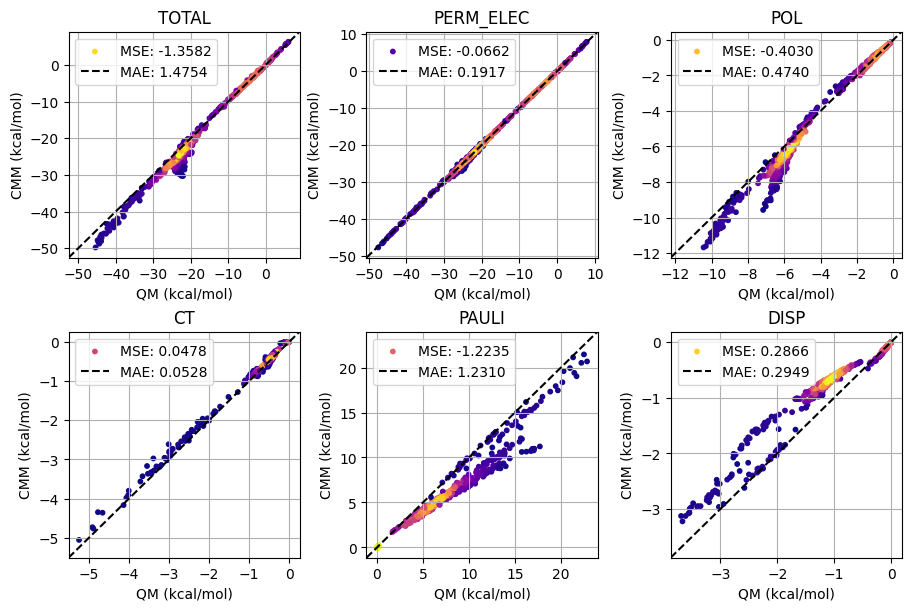

In [9]:
report_eda_cluster(trainer, data)

In [10]:
#ff.save('test.json')